# Part 1 — Customer Loyalty, RFM & CLV


# Data Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
olist_orders_df = pd.read_csv("olist_orders_dataset.csv")

In [3]:
olist_orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
95343,74d300a40f14d9bb630e966dad89198f,88492e86ca0506b9bbc06675a2d7c8d0,delivered,2018-07-18 11:38:09,2018-07-18 11:45:21,2018-07-19 14:21:00,2018-07-24 15:32:47,2018-08-10 00:00:00
33048,6917bf2ef92587d31987c8c01aa1b4e0,782439c1913d6f928285350906a9662f,delivered,2018-08-25 20:26:35,2018-08-25 20:35:13,2018-08-27 15:10:00,2018-08-28 20:56:30,2018-09-06 00:00:00
74024,94f506e669de10a239ec04627d90eef4,d8b4a91c31ba22e95b3c98a326d3dbe0,delivered,2018-06-01 15:08:16,2018-06-02 03:31:52,2018-06-04 12:17:00,2018-06-13 20:52:38,2018-07-04 00:00:00
38832,936b6d1c11f2b85ce1edfa34171b0e0d,02e5b5ecce34b118017c55151accfbe5,delivered,2018-07-30 22:59:30,2018-07-31 22:50:14,2018-08-01 15:59:00,2018-08-08 11:58:57,2018-08-15 00:00:00
69950,1f4ef92fe96573c57bbdf0fd5c284459,3ac5bc758161afdfbbea6eaa4c27996b,shipped,2018-08-04 16:03:47,2018-08-04 16:15:18,2018-08-06 13:09:00,NaN,2018-08-21 00:00:00


In [4]:
olist_orders_df.shape

(99441, 8)

In [5]:
olist_orders_df['order_id'].nunique()

99441

In [6]:
olist_order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")

In [7]:
olist_order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
100811,a297af9c433b5e1ac1290d8057386952,1,credit_card,3,112.09
85220,6f09086a54ed13a7f152d6339e2ee5a3,1,credit_card,1,143.49
6350,db2eafd064193f2bd9dd161490c09bd0,1,credit_card,4,195.91
84128,a3af1cceb020d287564458a7cd29f969,1,credit_card,1,74.06
3304,91394832e2cfea6fd2da6fe1b72df4c9,1,credit_card,6,82.55


In [8]:
olist_order_payments_df.shape

(103886, 5)

In [9]:
olist_p1_df = pd.merge(olist_orders_df,olist_order_payments_df,on="order_id")

In [10]:
olist_p1_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
65008,583ad689dbd7bd2d996f11aa82865ae5,ffa6c1b1855a12e84bae4eb85a60fc2a,delivered,2018-04-11 23:24:24,2018-04-13 02:11:14,2018-04-13 18:03:15,2018-05-07 19:32:26,2018-05-11 00:00:00,1,boleto,1,896.37
8956,9af6f205c7247ac28685a350094ce865,9a29bf9ecfdbd9acf4088d680a19fca1,delivered,2017-11-24 17:20:26,2017-11-24 20:55:56,2017-11-29 18:23:44,2018-01-08 15:19:06,2017-12-22 00:00:00,1,credit_card,10,398.86
74792,e72a8568c8622825a95439791f668e85,7d741f274b5f16487253c349ff12b703,delivered,2017-09-24 23:00:55,2017-09-24 23:15:18,2017-09-28 11:13:24,2017-10-04 17:26:25,2017-10-26 00:00:00,1,credit_card,2,83.68
60937,7441a7966b3ab1db2240ade4023df809,c82064d38030650cef4059e13d90ba39,delivered,2018-03-17 23:09:29,2018-03-17 23:27:51,2018-03-19 17:43:23,2018-03-27 01:42:12,2018-04-06 00:00:00,1,credit_card,1,169.29
103004,cb2a9cb383940ea9958340662d39e2d0,d0bae605ed6507129c12346c5d7e8c9e,delivered,2017-11-12 20:26:01,2017-11-12 20:46:16,2017-11-14 22:41:18,2017-11-20 13:09:33,2017-12-01 00:00:00,1,credit_card,3,207.46


In [11]:
olist_p1_df.shape

(103886, 12)

In [12]:
olist_p1_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [13]:
olist_p1_df.isnull().mean()*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.168454
order_delivered_carrier_date     1.817377
order_delivered_customer_date    3.014843
order_estimated_delivery_date    0.000000
payment_sequential               0.000000
payment_type                     0.000000
payment_installments             0.000000
payment_value                    0.000000
dtype: float64

In [14]:
olist_p1_df.duplicated().sum()

np.int64(0)

In [15]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"]).sum()

np.int64(4446)

In [16]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"],keep=False).sum()

np.int64(7407)

In [17]:
olist_p1_df[olist_p1_df.duplicated(subset=["order_id" , "customer_id"])]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
12,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,credit_card,1,8.34
23,83018ec114eee8641c97e08f7b4e926f,7f8c8b9c2ae27bf3300f670c3d478be8,delivered,2017-10-26 15:54:26,2017-10-26 16:08:14,2017-10-26 21:46:53,2017-11-08 22:22:00,2017-11-23 00:00:00,3,voucher,1,24.86
24,83018ec114eee8641c97e08f7b4e926f,7f8c8b9c2ae27bf3300f670c3d478be8,delivered,2017-10-26 15:54:26,2017-10-26 16:08:14,2017-10-26 21:46:53,2017-11-08 22:22:00,2017-11-23 00:00:00,1,credit_card,1,5.96
...,...,...,...,...,...,...,...,...,...,...,...,...
103773,0572c996d9b4a7645bb071a158a64bbb,874b661d62c1e74aafa401942f9d94cb,delivered,2017-11-20 21:53:20,2017-11-20 22:07:27,2017-11-22 00:32:47,2017-11-27 21:28:53,2017-12-11 00:00:00,1,credit_card,1,42.59
103782,4bafa54db6b060da198f23f810835969,48094f58f03bec9519bd0e004ce460df,delivered,2018-04-05 14:46:51,2018-04-05 15:09:52,2018-04-07 01:32:58,2018-04-30 21:41:07,2018-05-14 00:00:00,2,voucher,1,49.32
103783,4bafa54db6b060da198f23f810835969,48094f58f03bec9519bd0e004ce460df,delivered,2018-04-05 14:46:51,2018-04-05 15:09:52,2018-04-07 01:32:58,2018-04-30 21:41:07,2018-05-14 00:00:00,3,voucher,1,8.13
103877,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,2,voucher,1,64.37


In [18]:
olist_p1_df.drop_duplicates()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16


In [19]:
olist_p1_df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
payment_sequential                 int64
payment_type                         str
payment_installments               int64
payment_value                    float64
dtype: object

In [20]:
df_orders_payments=pd.DataFrame()
df_orders_payments[["order_id","customer_id","order_purchase_timestamp","payment_type"]]=olist_p1_df[["order_id","customer_id","order_purchase_timestamp","payment_type"]]

In [21]:
df_orders_payments.shape

(103886, 4)

In [22]:
df_orders_payments.drop_duplicates(subset="order_id",inplace=True)

In [23]:
df_orders_payments.shape

(99440, 4)

In [24]:
df_orders_payments

,order_id,customer_id,order_purchase_timestamp,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,credit_card
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,boleto
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,credit_card
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,credit_card
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,credit_card
...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,credit_card
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,credit_card
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,credit_card
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,credit_card


In [25]:
df_orders_payments.sample(5)

,order_id,customer_id,order_purchase_timestamp,payment_type
68046,ff74e94493932bd63924387d576ed9b9,d31dcc0549802457751f20cf5cad0dd5,2018-07-23 11:36:07,credit_card
52920,293b49dd2d7212a25cd82a02e0c984ef,fd6d24826df20a47edc27155e5c613ae,2017-11-09 19:16:07,credit_card
7970,d39a64bdd75efa842f23e443912321f8,a52ec7711669c58e970afdfb9ee74bb5,2018-02-24 13:18:25,boleto
56000,7c2aefdd602f9df2ae6eb835d3973974,187a820d7c72e9248b35ef98df3438c5,2017-10-18 05:04:06,credit_card
23646,a994ff8265aed38e21cb63b2d8402b09,bc8d0eaead98c6ac8afc8ef41f1f483e,2018-07-01 10:38:02,credit_card


In [26]:
df_orders_payments["total_payment_value"] = (olist_p1_df.groupby("order_id")["payment_value"].transform("sum"))

In [27]:
df_orders_payments[df_orders_payments["order_id"]=="e481f51cbdc54678b7cc49136f2d6af7"]

,order_id,customer_id,order_purchase_timestamp,payment_type,total_payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,credit_card,38.71


In [28]:
df_orders_payments.shape

(99440, 5)

In [29]:
df_orders_payments.order_id.nunique()

99440

In [30]:
customers_df = pd.read_csv("olist_customers_dataset.csv")

customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
41664,fdd0411bec46e2d9a15590016b897dc3,df53be64d8a262264d44f9b36a095f2f,14815,ibate,SP
42618,6b170d60eabcac609caaaf419e9e57f1,f121943f335b4993188fedd3852ea3aa,69037,manaus,AM
4361,ef60347fdedc32a90d201dabe721b525,5d5662cb1f1a87825976598fa2f4e33b,32432,ibirite,MG
82100,d9f2a8fcf629fb093b8e265d27fc8892,7bed3ef7d7fe924202459a0553307626,62810,icapui,CE
9907,b2b4d80645cd613edb31955f2e5f59d1,730dc8ae933c09adf0f7d56967e0c804,9843,sao bernardo do campo,SP


In [31]:
customers_df.shape

(99441, 5)

In [32]:
customers_df.customer_unique_id.value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [33]:
customer_orders_payments_df=pd.merge(df_orders_payments,customers_df,on="customer_id",how='inner')

In [34]:
customer_orders_payments_df

,order_id,customer_id,order_purchase_timestamp,payment_type,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,credit_card,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,boleto,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,credit_card,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,credit_card,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,credit_card,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,credit_card,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,credit_card,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,credit_card,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,credit_card,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [35]:
customer_orders_payments_df.payment_type.value_counts()

payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
not_defined        3
Name: count, dtype: int64

In [36]:
customer_orders_payments_df.dtypes

order_id                        str
customer_id                     str
order_purchase_timestamp        str
payment_type                    str
total_payment_value         float64
customer_unique_id              str
customer_zip_code_prefix      int64
customer_city                   str
customer_state                  str
dtype: object

In [37]:
customer_orders_payments_df['order_purchase_timestamp']=pd.to_datetime(customer_orders_payments_df['order_purchase_timestamp']).dt.normalize()

In [38]:
customer_orders_payments_df.dtypes

order_id                               str
customer_id                            str
order_purchase_timestamp    datetime64[us]
payment_type                           str
total_payment_value                float64
customer_unique_id                     str
customer_zip_code_prefix             int64
customer_city                          str
customer_state                         str
dtype: object

In [39]:
customer_orders_payments_df['order_purchase_timestamp'].sample(5)

59442   2018-08-26
12919   2018-01-25
90433   2017-07-07
85005   2017-07-22
56564   2018-05-14
Name: order_purchase_timestamp, dtype: datetime64[us]

# Analysis

In [40]:
newest_date=customer_orders_payments_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
newest_date

Timestamp('2018-10-18 00:00:00')

In [41]:
filtering_recency=(newest_date-customer_orders_payments_df['order_purchase_timestamp']).dt.days<90

In [42]:
customer_orders_payments_df[filtering_recency]

,order_id,customer_id,order_purchase_timestamp,payment_type,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,boleto,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,credit_card,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,2018-07-25,credit_card,32.70,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP
24,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,2018-08-09,boleto,104.11,9c9242ad7f1b52d926ea76778e1c0c57,18052,sorocaba,SP
34,b276e4f8c0fb86bd82fce576f21713e0,cf8ffeddf027932e51e4eae73b384059,2018-07-29,credit_card,188.41,6cbe8a392b76916e84c2faf69d0d0da0,13454,santa barbara d'oeste,SP
...,...,...,...,...,...,...,...,...,...
99393,079c9f53e6c3253320db701a645b0b9a,e5e0698e95094be297436cbd55c2dcad,2018-08-09,credit_card,98.23,531d6ca1ecce995a2317a0ca559e8c61,31030,belo horizonte,MG
99394,5597332b7eded552f104108f22b023e4,aaa423fb52f4106f477683490cbd5845,2018-08-15,credit_card,36.46,8a898880a61e551c80bacadfb4356255,6449,barueri,SP
99395,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,2018-08-02,credit_card,239.50,f690f0caffab80b6f849f08ba1692925,9330,maua,SP
99406,c2af225ac9a68a3c24500aa6fab006aa,f93c9e539a9705a57902c625b611e90c,2018-08-20,credit_card,43.87,a3adfb1ef257529c6abe81be7726a63f,1454,sao paulo,SP


In [43]:
churned_customers=customer_orders_payments_df[~filtering_recency].customer_unique_id.count()

In [44]:
100*churned_customers/(customer_orders_payments_df.customer_unique_id.count())

np.float64(90.75824617860016)

In [45]:
customer_orders_payments_df[filtering_recency].customer_unique_id.nunique()

9077

In [46]:
customer_orders_payments_df['customer_unique_id'].nunique()

96095

In [47]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts()

count
1     93098
2      2745
3       203
4        30
5         8
6         6
7         3
17        1
9         1
Name: count, dtype: int64

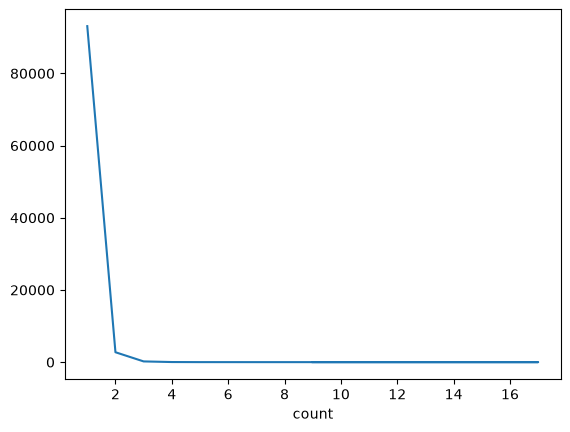

In [48]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot();

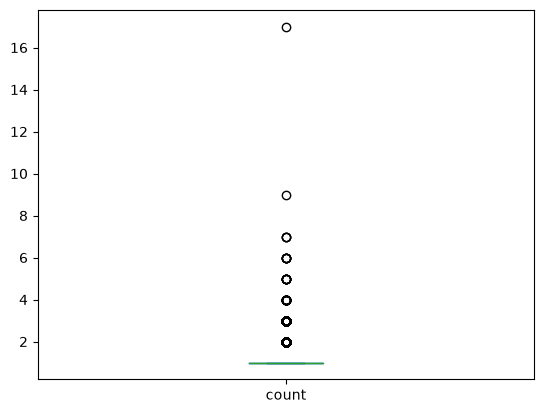

In [49]:
customer_orders_payments_df['customer_unique_id'].value_counts().plot(kind='box');

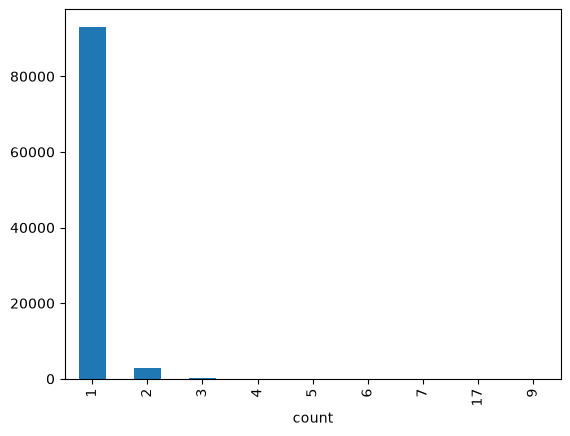

In [50]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot(kind='bar');

In [51]:
(customer_orders_payments_df['customer_unique_id'].value_counts()>=2).sum()

np.int64(2997)

In [52]:
100*(customer_orders_payments_df['customer_unique_id'].value_counts()>=2).mean()

np.float64(3.1187886986835944)

**Percentage of ordering 2 or more is 3.12 %**


In [53]:
frequent_customers = (customer_orders_payments_df['customer_unique_id'].value_counts())

customers_2_plus = frequent_customers[frequent_customers >= 2].index

recent_customers = (customer_orders_payments_df.loc[filtering_recency,'customer_unique_id'].unique())

loyal_customers = set(customers_2_plus) & set(recent_customers)

len(loyal_customers)

326

In [54]:
326/96095*100

0.3392476195431604

In [55]:
customer_orders_payments_df['customer_unique_id'].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
6359f309b166b0196dbf7ad2ac62bb5a     1
da62f9e57a76d978d02ab5362c509660     1
737520a9aad80b3fbbdad19b66b37b30     1
5097a5312c8b157bb7be58ae360ef43c     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 96095, dtype: int64

In [56]:
customer_orders_payments_df[filtering_recency]['customer_unique_id'].value_counts().value_counts()

count
1    8975
2      93
3       7
4       2
Name: count, dtype: int64

## Customer Lifetime Value

In [57]:
CLV_df=customer_orders_payments_df.groupby('customer_unique_id').total_payment_value.agg(['sum','count','mean'])

In [58]:
CLV_df.sort_values(by='mean',ascending=False)

,sum,count,mean
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,13664.08,1,13664.08
763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,6929.31
459bef486812aa25204be022145caa62,6922.21,1,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1,6726.66
...,...,...,...
b33336f46234b24a613ad9064d13106d,10.89,1,10.89
bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,1,10.07
317cfc692e3f86c45c95697c61c853a6,9.59,1,9.59


In [59]:
total_revenue=CLV_df['sum'].sum()

In [60]:
CLV_df.sort_values(by='count',ascending=False)

,sum,count,mean
customer_unique_id,,,
8d50f5eadf50201ccdcedfb9e2ac8455,927.63,17,54.566471
3e43e6105506432c953e165fb2acf44c,1172.66,9,130.295556
6469f99c1f9dfae7733b25662e7f1782,758.83,7,108.404286
ca77025e7201e3b30c44b472ff346268,1122.72,7,160.388571
1b6c7548a2a1f9037c1fd3ddfed95f33,959.01,7,137.001429
...,...,...,...
5657dfebff5868c4dc7e8355fea865c4,105.38,1,105.380000
5657596addb4d7b07b32cd330614bdf8,189.26,1,189.260000
5656eb169546146caeab56c3ffc3d268,128.87,1,128.870000


**2 customers have orders with 0 total cost, is it input error in the data, special offers or exploiting glitch?**

## days between orders

In [61]:
average_days_df = customer_orders_payments_df.sort_values(["customer_unique_id", "order_purchase_timestamp"])


In [62]:
average_days_df["order_number"] = (average_days_df.groupby("customer_unique_id").cumcount() + 1)


In [63]:
average_days_df["previous_order_date"] = (average_days_df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1))


In [64]:
average_days_df["days_between_orders"] = (average_days_df["order_purchase_timestamp"]-average_days_df["previous_order_date"]).dt.days

In [65]:
average_days_df[average_days_df["order_number"]==2].days_between_orders.mean()

np.float64(80.34834834834835)

## Single order customers

In [66]:
100*(customer_orders_payments_df['customer_unique_id'].value_counts()==1).mean()

np.float64(96.88121130131641)

**96.88 % of the customers only ordered once** 

In [67]:
CLV_df[CLV_df['count']>1]['sum'].mean()

np.float64(314.9892258925592)

In [68]:
CLV_df[CLV_df['count']==1]['sum'].mean()

np.float64(161.81711110872413)

In [69]:
CLV_differance = CLV_df[CLV_df['count']>1]['sum'].mean()-CLV_df[CLV_df['count']==1]['sum'].mean()

In [70]:
extra_revenue=CLV_df['mean'].count()*0.05*CLV_differance
extra_revenue

np.float64(735953.7185076316)

In [71]:
potential_revenue=100*extra_revenue/total_revenue
potential_revenue

np.float64(4.597161580097821)

In [72]:
revenue_comparison=pd.DataFrame({
    "Class": ["Current Revenue", "Potential Revenue"],
    "Revenue": [total_revenue, extra_revenue+total_revenue]})

In [73]:
revenue_comparison.set_index("Class", inplace=True)

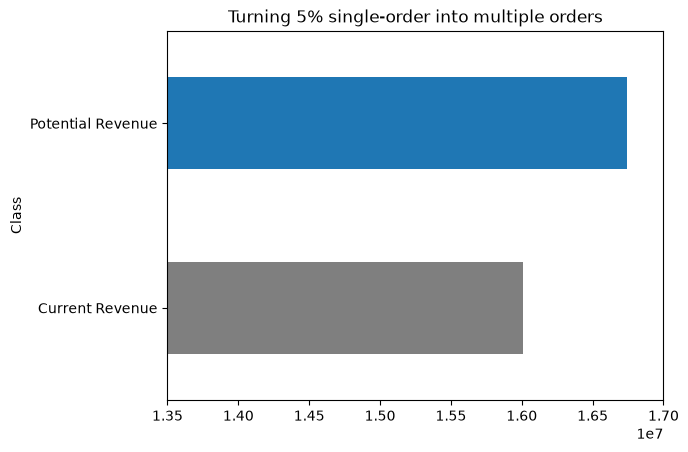

In [74]:
ax=revenue_comparison.Revenue.plot(kind='barh',title='Turning 5% single-order into multiple orders',color=['tab:grey','tab:blue']);
ax.set_xlim(13_500_000, 17_000_000);

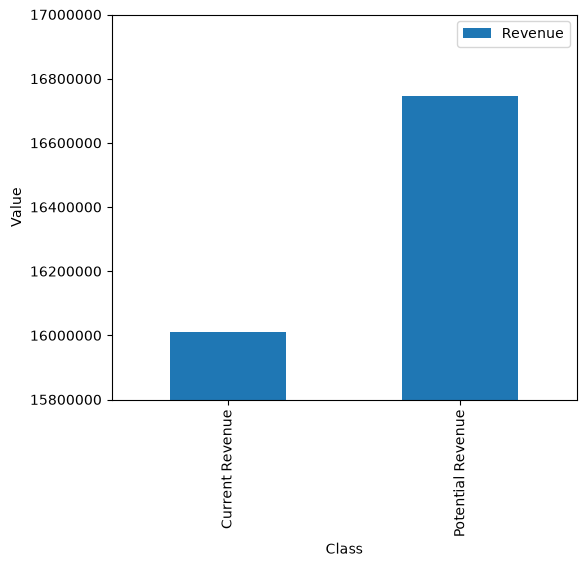

In [75]:
ax = revenue_comparison.plot(kind="bar", figsize=(6, 5))

ax.set_ylim(15_800_000, 17_000_000)
ax.set_ylabel("Value")
ax.ticklabel_format(style="plain", axis="y")

**Turning 5 % of the single order customers to a repeat customers will return an estimated revenue of 735,954 R$**

**4.6 % Extra Revenue**

In [76]:
multiple_orders=pd.DataFrame(customer_orders_payments_df['customer_unique_id'].value_counts()>1)

In [77]:
multiple_orders.columns = ['multiple_orders']

In [78]:
multiple_orders

,multiple_orders
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,True
3e43e6105506432c953e165fb2acf44c,True
ca77025e7201e3b30c44b472ff346268,True
1b6c7548a2a1f9037c1fd3ddfed95f33,True
6469f99c1f9dfae7733b25662e7f1782,True
...,...
6359f309b166b0196dbf7ad2ac62bb5a,False
da62f9e57a76d978d02ab5362c509660,False
737520a9aad80b3fbbdad19b66b37b30,False


In [79]:
customer_orders_payments_df2=pd.merge(customer_orders_payments_df,multiple_orders,on="customer_unique_id",how='inner')

In [80]:
customer_orders_payments_df2

,order_id,customer_id,order_purchase_timestamp,payment_type,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,multiple_orders
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,credit_card,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,boleto,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,credit_card,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18,credit_card,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13,credit_card,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,False
...,...,...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09,credit_card,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,False
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06,credit_card,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,False
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27,credit_card,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,False
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08,credit_card,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,False


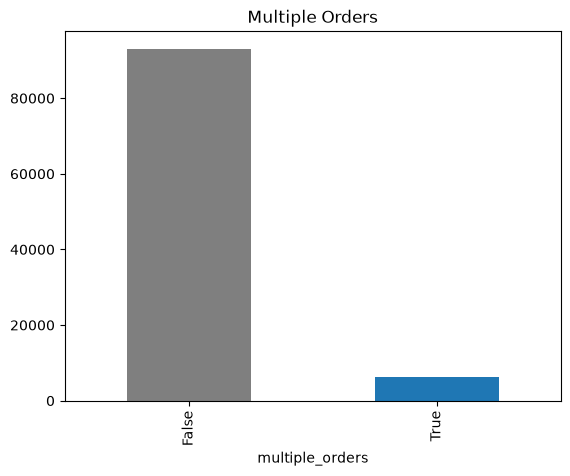

In [81]:
customer_orders_payments_df2.multiple_orders.value_counts().plot(kind='bar',title='Multiple Orders',color=['tab:grey','tab:blue']);

In [82]:
#(customer_orders_payments_df['customer_unique_id'].value_counts()>1).sum()

# Part 2 — Customer Growth & Seasonality


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
df = orders.merge(customers, on='customer_id')
df['date'] = pd.to_datetime(df['order_purchase_timestamp'])

In [3]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02-13 21:18:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,2017-03-09 09:54:05
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,2018-02-06 12:58:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,2017-08-27 14:46:43
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2018-01-08 21:28:27


In [4]:
df.describe()

,customer_zip_code_prefix,date
count,99441.000000,99441
mean,35137.474583,2017-12-31 08:43:12.776581
min,1003.000000,2016-09-04 21:15:19
25%,11347.000000,2017-09-12 14:46:19
50%,24416.000000,2018-01-18 23:04:36
75%,58900.000000,2018-05-04 15:42:16
max,99990.000000,2018-10-17 17:30:18
std,29797.938996,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  str           
 4   order_approved_at              99281 non-null  str           
 5   order_delivered_carrier_date   97658 non-null  str           
 6   order_delivered_customer_date  96476 non-null  str           
 7   order_estimated_delivery_date  99441 non-null  str           
 8   customer_unique_id             99441 non-null  str           
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  str           
 11  customer_state            

In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99436    False
99437    False
99438    False
99439    False
99440    False
Length: 99441, dtype: bool

In [7]:
df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,date
58985,e56d6e36145ccad4895538d379ac3552,b97925383862944801250c9bcc43bd10,delivered,2017-08-17 20:01:07,2017-08-17 20:44:27,2017-08-18 20:08:01,2017-08-24 18:08:13,2017-09-14 00:00:00,8ce938b7447a8327dadf2a50c43ac271,11701,praia grande,SP,2017-08-17 20:01:07
83456,fb98d749a39a0e47d64ec1e9cf90bb10,528fef52545ccd3a24969948244873f2,delivered,2017-11-29 10:48:08,2017-11-29 11:00:24,2017-11-30 22:22:24,2017-12-21 20:13:36,2017-12-22 00:00:00,3a51663803fd832d4dc71eda8143d88a,29480,muqui,ES,2017-11-29 10:48:08
1358,a0b05780db06986cd81518fc9cc9b34d,e95ac603dd00da603acf38d05e55d781,delivered,2017-11-24 19:58:16,2017-11-24 23:13:19,2017-11-28 16:41:25,2017-11-29 20:37:08,2017-12-11 00:00:00,09c361fed7245568f0f104496ed4f92f,7072,guarulhos,SP,2017-11-24 19:58:16
72333,80e8a0b7128272e407375016c1fe666d,f3dc55ecb71ebe4066a6efc57c6593b3,delivered,2018-04-05 21:00:26,2018-04-05 21:15:11,2018-04-07 01:11:24,2018-04-14 17:48:45,2018-04-23 00:00:00,e50f2d7844c4b32abba3df02aaae0952,6535,santana de parnaiba,SP,2018-04-05 21:00:26
65125,3da024a05d8a0394947d8a4dbfacb15b,da42c4f5f48db6c2e09ae4fef214098a,delivered,2018-06-24 21:10:34,2018-06-24 21:33:53,2018-06-25 14:36:00,2018-07-03 22:12:16,2018-08-01 00:00:00,22f15b9a5e5b4c1e07d1bd53774fc7ef,20210,rio de janeiro,RJ,2018-06-24 21:10:34


In [8]:
first_purchases = df.groupby('customer_unique_id')['date'].min()

first_purchases = first_purchases[(first_purchases >= '2017-01-01') & (first_purchases <= '2018-08-31')]

monthly_acq = first_purchases.dt.strftime('%Y-%m').value_counts().sort_index()

In [9]:
events = {
    "Consumer Day '17": ('2017-03-12', '2017-03-18'),
    "Easter '17": ('2017-04-10', '2017-04-16'),
    "Black Friday '17": ('2017-11-20', '2017-11-27'),
    "Christmas '17": ('2017-12-18', '2017-12-25'),
    "Consumer Day '18": ('2018-03-12', '2018-03-18'),
    "Easter '18": ('2018-03-26', '2018-04-01'),
}

In [10]:
event_counts = {
    label: first_purchases.between(start, end).sum()
    for label, (start, end) in events.items()
}

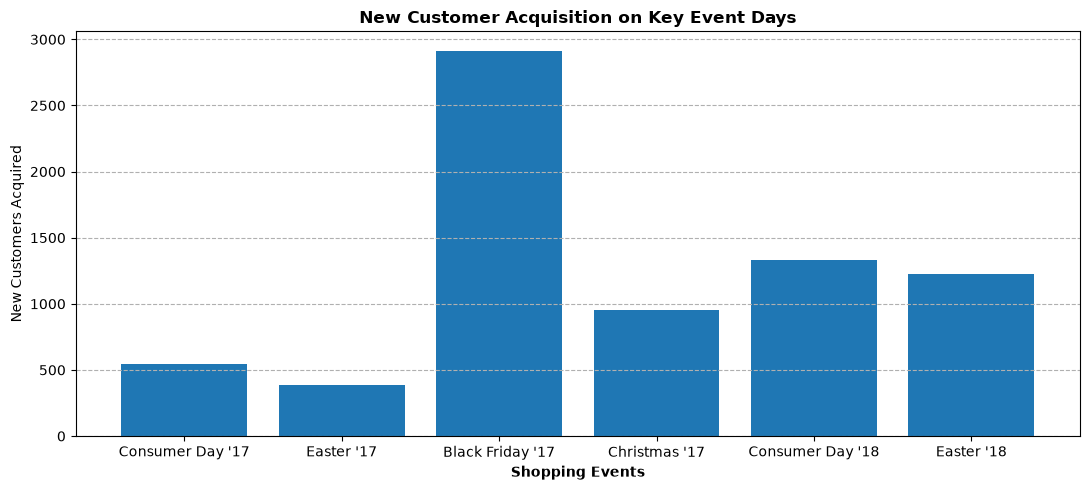

In [11]:
plt.figure(figsize=(11, 5))
  
bars = plt.bar(event_counts.keys(), event_counts.values())

plt.title(
    'New Customer Acquisition on Key Event Days',
    fontweight='bold',
)
plt.xlabel('Shopping Events', fontweight='bold')
plt.ylabel('New Customers Acquired')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

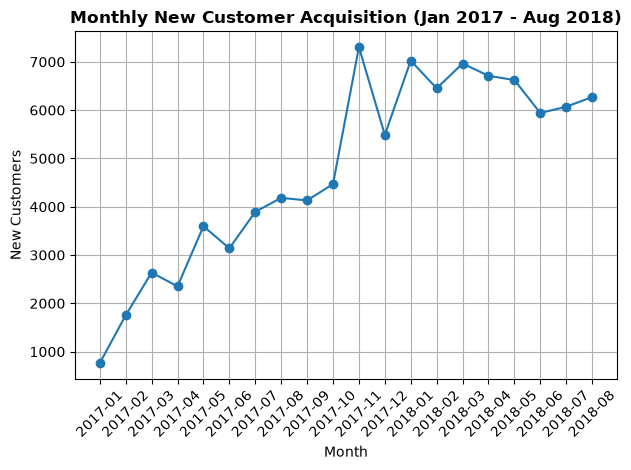

In [12]:
plt.plot(monthly_acq.index, monthly_acq.values, marker='o')
plt.title('Monthly New Customer Acquisition (Jan 2017 - Aug 2018)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('New Customers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()

repeat_buyers_count = (orders_per_customer > 1).sum()
single_buyers_count = (orders_per_customer == 1).sum()
total_customers = len(orders_per_customer)

In [15]:
single_buyers_count

np.int64(93099)

In [17]:
repeat_buyers_count

np.int64(2997)

In [20]:
repeat_percentage = (repeat_buyers_count/single_buyers_count) * 100
repeat_percentage

np.float64(3.2191538040150807)

# Part 3 — Products, Customer Segments & Regions


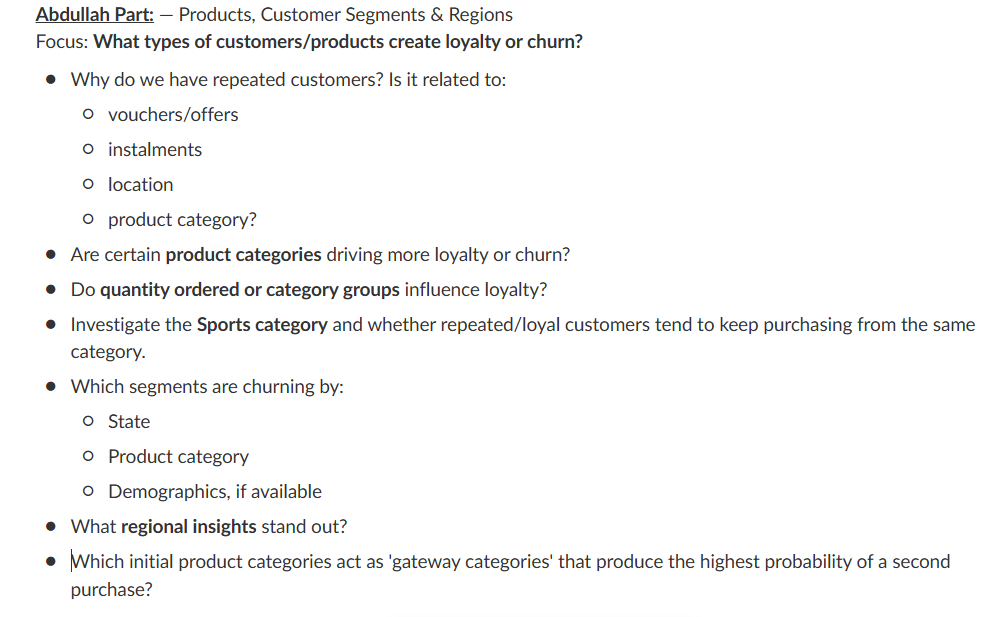

In [2]:
import pandas as pd

In [3]:
orders_df=pd.read_csv("olist_orders_dataset.csv")
orders_items_df=pd.read_csv("olist_order_items_dataset.csv")
orders_payments_df=pd.read_csv("olist_order_payments_dataset.csv")
customers_df=pd.read_csv("olist_customers_dataset.csv")
products_df = pd.read_csv("olist_products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

In [4]:
orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [6]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [7]:
orders_df.duplicated().sum()

np.int64(0)

In [8]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
# tatal price column
orders_items_df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
orders_items_df.duplicated().sum()

np.int64(0)

In [11]:
orders_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [12]:
orders_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
orders_items_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [14]:
orders_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [15]:
orders_payments_df.duplicated().sum()

np.int64(0)

In [16]:
orders_payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [17]:
orders_payments_df.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [18]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [19]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [20]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [21]:
products_df.duplicated().sum()

np.int64(0)

In [22]:
# little bet weard
products_df.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [23]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [24]:
orders_items_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [25]:
orders_payments_df.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [26]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [27]:
products_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [28]:
category_translation_df.columns

Index(['product_category_name', 'product_category_name_english'], dtype='str')

In [29]:
len(orders_df)

99441

In [30]:
orders_df.order_id.nunique()

99441

In [31]:
len(orders_items_df)

112650

In [32]:
orders_items_df['order_id'].nunique()

98666

In [33]:
len(orders_payments_df)


103886

In [34]:
orders_payments_df['order_id'].nunique()


99440

In [35]:
len(customers_df)

99441

In [36]:
customers_df['customer_id'].nunique()

99441

In [37]:
customers_df['customer_unique_id'].nunique()

96096

In [38]:
len(products_df)

32951

In [39]:
products_df['product_id'].nunique()

32951

In [40]:
orders_df['customer_id'].isin(customers_df['customer_id']).value_counts()

customer_id
True    99441
Name: count, dtype: int64

In [41]:
for_customer=pd.merge(orders_df,customers_df,on='customer_id',how='left')

In [42]:
for_customer.shape

(99441, 12)

In [43]:
for_customer.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [44]:
len(category_translation_df)

71

In [45]:
category_translation_df.product_category_name.unique()

<ArrowStringArray>
[                                  'beleza_saude',
                         'informatica_acessorios',
                                     'automotivo',
                                'cama_mesa_banho',
                               'moveis_decoracao',
                                  'esporte_lazer',
                                     'perfumaria',
                          'utilidades_domesticas',
                                      'telefonia',
                             'relogios_presentes',
                              'alimentos_bebidas',
                                          'bebes',
                                      'papelaria',
                       'tablets_impressao_imagem',
                                     'brinquedos',
                                 'telefonia_fixa',
                             'ferramentas_jardim',
                    'fashion_bolsas_e_acessorios',
                                'eletroportateis',
            

In [46]:
for_product=pd.merge(orders_items_df,products_df,on='product_id',how='left')

In [47]:
for_product.shape

(112650, 15)

In [48]:
products_df.product_category_name.unique()

<ArrowStringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
            

In [49]:
# how to work with them?
# add them by using google translation
product_categories = set(products_df['product_category_name'].dropna().unique())
translated_categories = set(category_translation_df['product_category_name'].dropna().unique())

product_categories - translated_categories

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}

In [50]:
category_translation_df['product_category_name']

0                      beleza_saude
1            informatica_acessorios
2                        automotivo
3                   cama_mesa_banho
4                  moveis_decoracao
                  ...              
66                           flores
67               artes_e_artesanato
68                  fraldas_higiene
69    fashion_roupa_infanto_juvenil
70               seguros_e_servicos
Name: product_category_name, Length: 71, dtype: str

In [51]:
missing_data=pd.DataFrame({'product_category_name':['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
                           'product_category_name_english':['pc_gamer','portable_kitchen_food_preparers']})
category_translation_df=pd.concat([missing_data,category_translation_df], ignore_index=True)

In [52]:
category_translation_df.shape

(73, 2)

In [53]:
for_product=pd.merge(for_product,category_translation_df,on='product_category_name', how='left')

In [54]:
for_product.shape

(112650, 16)

In [55]:
for_product.product_category_name_english.isnull().sum()

np.int64(1603)

In [56]:
for_product['product_category_name'].isna().sum()

np.int64(1603)

In [57]:
for_payment=pd.merge(for_customer,orders_payments_df,on='order_id',how='left')

In [58]:
for_payment.shape

(103887, 16)

In [59]:
orders_payments_df.shape

(103886, 5)

- for_customer → customer/region
- for_product → products/categories
- for_payment → payment/voucher/installments

In [60]:
for_customer.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='str')

In [61]:
for_product.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

In [62]:
for_payment.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

---

In [63]:
for_customer['customer_unique_id'].isnull().sum()

np.int64(0)

In [64]:
for_customer.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR


In [65]:
order_count=for_customer.groupby('customer_unique_id')['order_id'].count()

In [66]:
repet_customer=order_count[order_count>=2]

In [67]:
order_count

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: order_id, Length: 96096, dtype: int64

In [68]:
for_customer['order_count']= for_customer['customer_unique_id'].map(order_count)

In [69]:
for_customer[['customer_unique_id', 'order_count']].head(2)

,customer_unique_id,order_count
0,7c396fd4830fd04220f754e42b4e5bff,2
1,af07308b275d755c9edb36a90c618231,1


In [70]:
import numpy as np

In [71]:
for_customer['customer_type'] = np.where(
    for_customer['order_count'] == 1,
    'one-time',
    'repeat'
)

In [72]:
for_customer[['customer_unique_id', 'order_count','customer_type']].head(2)

,customer_unique_id,order_count,customer_type
0,7c396fd4830fd04220f754e42b4e5bff,2,repeat
1,af07308b275d755c9edb36a90c618231,1,one-time


In [73]:
for_customer.groupby(['customer_state', 'customer_type'])['customer_unique_id'].nunique()

customer_state  customer_type
AC              one-time            73
                repeat               4
AL              one-time           388
                repeat              13
AM              one-time           140
                repeat               3
AP              one-time            66
                repeat               1
BA              one-time          3182
                repeat              95
CE              one-time          1289
                repeat              24
DF              one-time          2010
                repeat              65
ES              one-time          1906
                repeat              58
GO              one-time          1886
                repeat              66
MA              one-time           708
                repeat              18
MG              one-time         10911
                repeat             348
MS              one-time           675
                repeat              19
MT              one-time          

In [74]:
state_counts = for_customer.groupby(
    ['customer_state', 'customer_type']
)['customer_unique_id'].nunique().unstack()

state_counts['repeat_percentage'] = (
    state_counts['repeat'] /
    (state_counts['repeat'] + state_counts['one-time'])
) * 100

In [75]:
state_counts.sort_values('repeat_percentage', ascending=False)

customer_type,one-time,repeat,repeat_percentage
customer_state,,,
AC,73,4,5.194805
RO,229,11,4.583333
MT,845,31,3.538813
RJ,11955,429,3.464147
GO,1886,66,3.381148
SP,38989,1313,3.257903
AL,388,13,3.241895
SE,331,11,3.216374
RS,5108,169,3.202577


In [76]:
import matplotlib.pyplot as plt

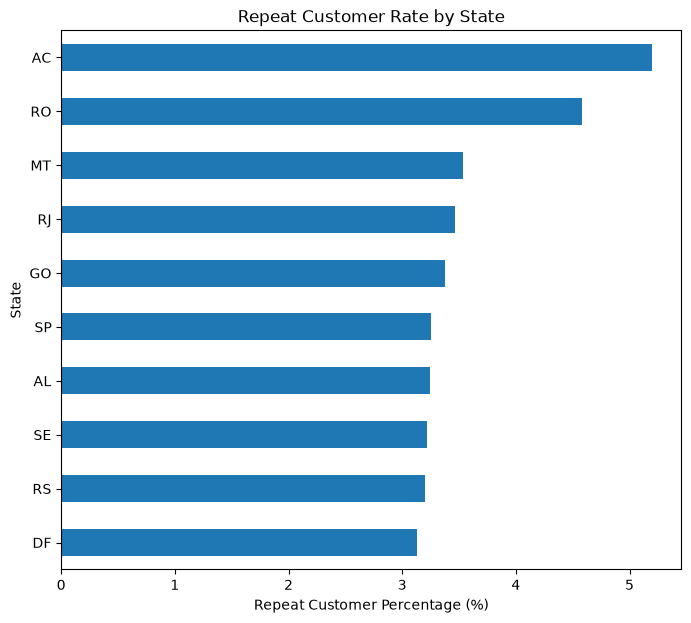

In [127]:
state_counts.sort_values('repeat_percentage').tail(10).plot(
    kind='barh',
    y='repeat_percentage',
    figsize=(8, 7),
    legend=False
)

plt.xlabel('Repeat Customer Percentage (%)')
plt.ylabel('State')
plt.title('Repeat Customer Rate by State')
plt.show()

In [78]:
for_product = pd.merge(
    for_product,
    for_customer[['order_id', 'customer_type']],
    on='order_id',
    how='left'
)

In [79]:
category_counts = for_product.groupby(
    ['product_category_name_english', 'customer_type']
)['order_id'].nunique().unstack(fill_value=0)

In [80]:
category_counts['repeat_percentage'] = (
    category_counts['repeat'] /
    (category_counts['repeat'] + category_counts['one-time']) * 100
)

In [81]:
category_counts.sort_values(
    'repeat_percentage',
    ascending=False
).head(5)

customer_type,one-time,repeat,repeat_percentage
product_category_name_english,,,
arts_and_craftmanship,18,5,21.739130
home_appliances,626,138,18.062827
la_cuisine,11,2,15.384615
furniture_bedroom,82,13,13.684211
fashio_female_clothing,34,5,12.820513


In [82]:
category_counts['total'] = (
    category_counts['one-time'] + category_counts['repeat']
)

category_filtered = category_counts[
    category_counts['total'] >= 100
]

category_filtered.sort_values(
    'repeat_percentage',
    ascending=False
).head(10)

customer_type,one-time,repeat,repeat_percentage,total
product_category_name_english,,,,
home_appliances,626,138,18.062827,764
fashion_bags_accessories,1634,230,12.339056,1864
fashion_male_clothing,100,12,10.714286,112
drinks,269,28,9.427609,297
bed_bath_table,8543,874,9.281087,9417
furniture_decor,5852,597,9.257249,6449
furniture_living_room,385,37,8.767773,422
fashion_shoes,219,21,8.750000,240
air_conditioning,231,22,8.695652,253


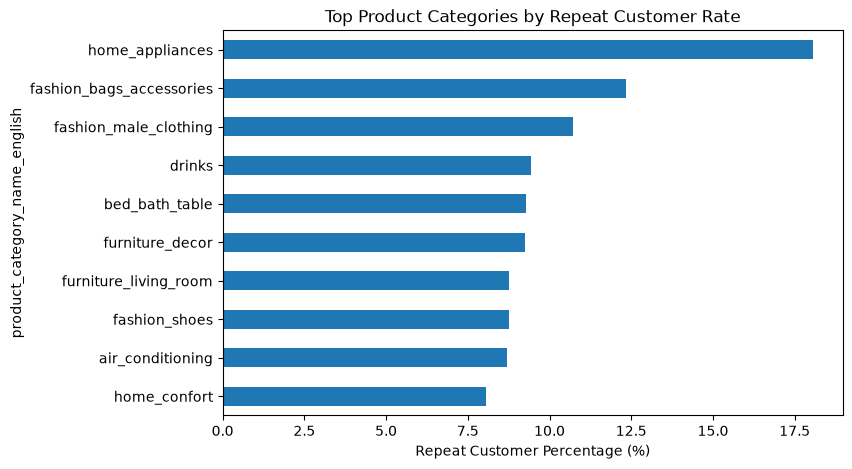

In [83]:
category_filtered.nlargest(10, 'repeat_percentage')['repeat_percentage'].sort_values(ascending=True).plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('Repeat Customer Percentage (%)')
plt.title('Top Product Categories by Repeat Customer Rate')
plt.show()

In [84]:
for_payment['order_count'] = for_payment['customer_unique_id'].map(order_count)


In [85]:
for_payment['customer_type'] = np.where(
    for_payment['order_count'] == 1,
    'one-time',
    'repeat'
)

In [86]:
for_payment.groupby('customer_type')['payment_type'].value_counts()

customer_type  payment_type
one-time       credit_card     71906
               boleto          18600
               voucher          5205
               debit_card       1450
               not_defined         2
repeat         credit_card      4889
               boleto           1184
               voucher           570
               debit_card         79
               not_defined         1
Name: count, dtype: int64

In [87]:
payment_percent = for_payment.groupby('customer_type')['payment_type'].value_counts(normalize=True) * 100

payment_percent

customer_type  payment_type
one-time       credit_card     74.005537
               boleto          19.143089
               voucher          5.356977
               debit_card       1.492338
               not_defined      0.002058
repeat         credit_card     72.720512
               boleto          17.611185
               voucher          8.478358
               debit_card       1.175071
               not_defined      0.014874
Name: proportion, dtype: float64

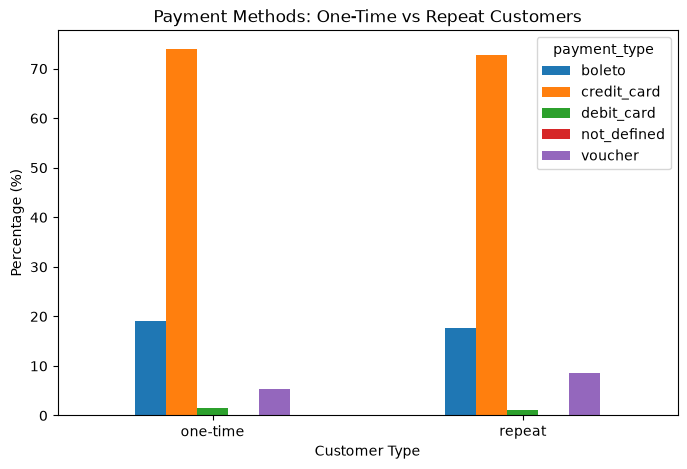

In [88]:
# Voucher usage is higher among repeat customers (8.48%) than one-time customers (5.36%).
payment_chart = payment_percent.unstack()

payment_chart.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.ylabel('Percentage (%)')
plt.xlabel('Customer Type')
plt.title('Payment Methods: One-Time vs Repeat Customers')
plt.xticks(rotation=0)
plt.show()

In [89]:
for_payment.groupby('customer_type')['payment_installments'].mean()

customer_type
one-time    2.830810
repeat      3.179087
Name: payment_installments, dtype: float64

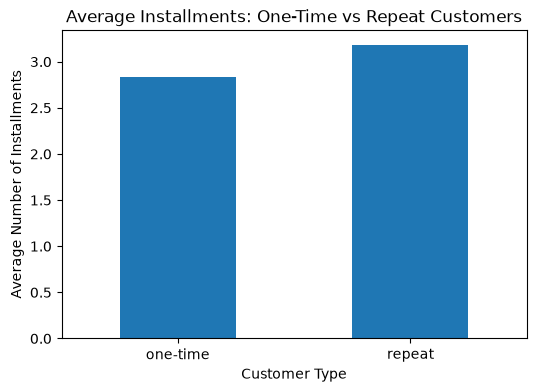

In [90]:
for_payment.groupby('customer_type')['payment_installments'].mean().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.ylabel('Average Number of Installments')
plt.xlabel('Customer Type')
plt.title('Average Installments: One-Time vs Repeat Customers')
plt.xticks(rotation=0)
plt.show()

---

Are certain product categories driving more loyalty or churn?-->Home Appliances had the highest repeat-customer rate among categories with at least 100 orders (18.06%), suggesting stronger repeat purchasing in this category.

---

In [91]:
order_quantity = for_product.groupby(
    ['order_id', 'customer_type']
).size()

In [92]:
order_quantity.value_counts(normalize=True)*100

1     90.064460
2      7.617619
3      1.339874
4      0.511828
5      0.206758
6      0.200677
7      0.022297
8      0.008108
10     0.008108
12     0.005068
11     0.004054
9      0.003041
20     0.002027
15     0.002027
14     0.002027
13     0.001014
21     0.001014
Name: proportion, dtype: float64

In [93]:
order_quantity.groupby('customer_type').mean()

customer_type
one-time    1.136870
repeat      1.213793
dtype: float64

Repeat customers purchase slightly more items per order (1.21) than one-time customers (1.14). However, the difference is small, suggesting that order quantity has only a weak association with repeat purchasing.

---

In [94]:
for_product = for_product.merge(
    for_customer[['customer_unique_id', 'order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

In [95]:
for_product['order_purchase_timestamp'] = pd.to_datetime(
    for_product['order_purchase_timestamp']
)

In [96]:
for_product = for_product.sort_values(
    ['customer_unique_id', 'order_purchase_timestamp']
)

In [97]:
for_product[
    for_product['product_category_name_english'].str.contains(
        'sport'
    )
]['product_category_name_english'].unique()

<ArrowStringArray>
['sports_leisure', 'fashion_sport']
Length: 2, dtype: str

In [98]:
sports_repeat = for_product[
    (
        (for_product['product_category_name_english'] == 'sports_leisure') |
        (for_product['product_category_name_english'] == 'fashion_sport')
    )
    & (for_product['customer_type'] == 'repeat')
]

sports_repeat['customer_unique_id'].nunique()

410

In [99]:
sports_customer_ids = sports_repeat['customer_unique_id'].unique()

sports_customer_history = for_product[
    for_product['customer_unique_id'].isin(sports_customer_ids)
]

In [100]:
sports_customer_history['order_number'] = (
    sports_customer_history
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .rank(method='dense')
)

In [101]:
later_orders = sports_customer_history[
    sports_customer_history['order_number'] > 1
]

In [102]:
sports_again = later_orders.groupby('customer_unique_id')[
    'product_category_name_english'
].apply(
    lambda x: x.isin(['sports_leisure', 'fashion_sport']).any()
)

In [103]:
sports_again.value_counts(normalize=True) * 100

product_category_name_english
True     70.380435
False    29.619565
Name: proportion, dtype: float64

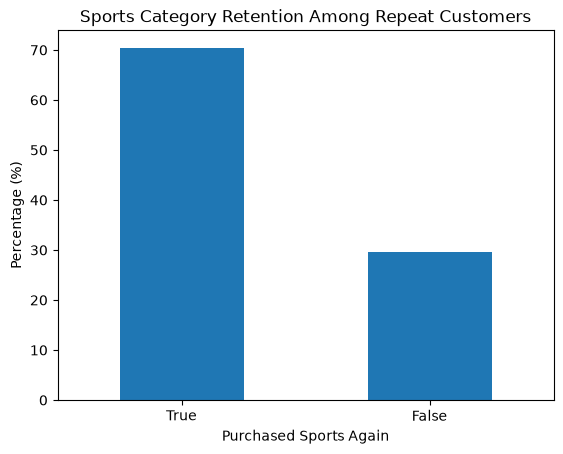

In [104]:
(sports_again.value_counts(normalize=True) * 100).plot(kind='bar')

plt.ylabel('Percentage (%)')
plt.xlabel('Purchased Sports Again')
plt.title('Sports Category Retention Among Repeat Customers')
plt.xticks(rotation=0)
plt.show()

---

In [105]:
for_customer['order_purchase_timestamp'] = pd.to_datetime(
    for_customer['order_purchase_timestamp'].astype(str)
)

In [106]:
last_purchase = for_customer.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].max()

In [107]:
reference_date = for_customer['order_purchase_timestamp'].max()

In [108]:
inactivity_days = (reference_date - last_purchase).dt.days

In [109]:
inactivity_days.head(3)

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    160
0000b849f77a49e4a4ce2b2a4ca5be3f    163
0000f46a3911fa3c0805444483337064    585
Name: order_purchase_timestamp, dtype: int64

In [110]:
churn_status = inactivity_days >= 90

In [111]:
churn_status.value_counts(normalize=True) * 100

order_purchase_timestamp
True     90.205628
False     9.794372
Name: proportion, dtype: float64

In [112]:
customer_churn = pd.DataFrame({
    'inactivity_days': inactivity_days,
    'churned': churn_status
})

In [113]:
customer_churn = customer_churn.merge(
    for_customer[['customer_unique_id', 'customer_state']].drop_duplicates('customer_unique_id'),
    on='customer_unique_id',
    how='left'
)

In [114]:
state_churn = customer_churn.groupby(
    'customer_state'
)['churned'].mean() * 100

state_churn.sort_values(ascending=False)

customer_state
AP    97.014925
RR    95.555556
AL    94.250000
RO    94.142259
MA    93.379310
CE    93.368902
RN    93.037975
MT    92.457143
PA    92.413066
PI    92.323651
SC    92.122414
ES    92.057026
GO    91.799077
RS    91.793025
TO    91.575092
BA    91.272505
RJ    91.251313
PE    91.147132
MG    91.087613
AC    90.909091
AM    90.909091
MS    90.764791
PR    90.432288
PB    90.154440
DF    89.001447
SE    88.823529
SP    88.594401
Name: churned, dtype: float64

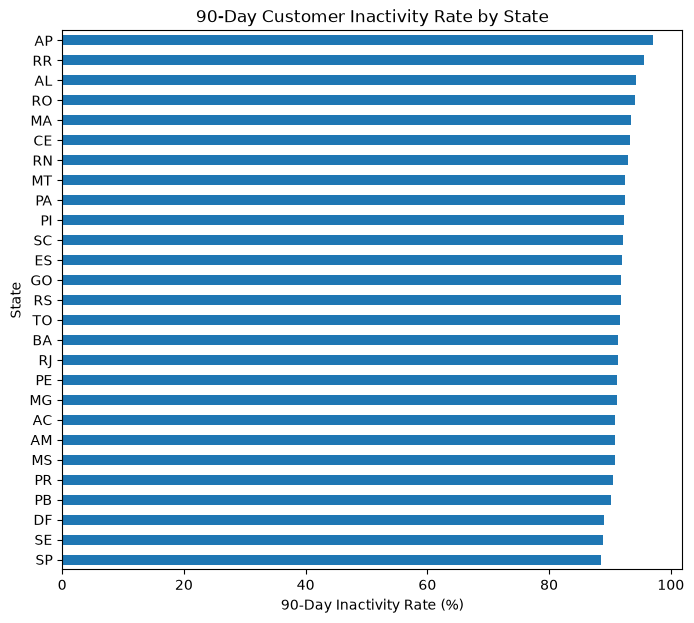

In [115]:
state_churn.sort_values().plot(
    kind='barh',
    figsize=(8, 7)
)

plt.xlabel('90-Day Inactivity Rate (%)')
plt.ylabel('State')
plt.title('90-Day Customer Inactivity Rate by State')
plt.show()

In [116]:
for_product['churned'] = for_product['customer_unique_id'].map(churn_status)

In [117]:
category_churn = for_product.groupby(
    'product_category_name_english'
)['churned'].mean() * 100

category_churn.sort_values(ascending=False)

product_category_name_english
cds_dvds_musicals                        100.000000
furniture_mattress_and_upholstery        100.000000
la_cuisine                               100.000000
tablets_printing_image                   100.000000
security_and_services                    100.000000
                                            ...    
party_supplies                            67.441860
small_appliances_home_oven_and_coffee     65.789474
pc_gamer                                  55.555556
arts_and_craftmanship                     25.000000
portable_kitchen_food_preparers           13.333333
Name: churned, Length: 73, dtype: float64

In [118]:
category_size = for_product.groupby(
    'product_category_name_english'
)['customer_unique_id'].nunique()

category_churn_filtered = category_churn[
    category_size >= 100
]

category_churn_filtered.sort_values(ascending=False).head(10)

product_category_name_english
fashion_underwear_beach           97.709924
fashion_shoes                     96.946565
market_place                      96.463023
office_furniture                  95.978711
cool_stuff                        95.258166
industry_commerce_and_business    94.776119
garden_tools                      94.455947
small_appliances                  94.108984
fixed_telephony                   93.939394
fashion_male_clothing             93.939394
Name: churned, dtype: float64

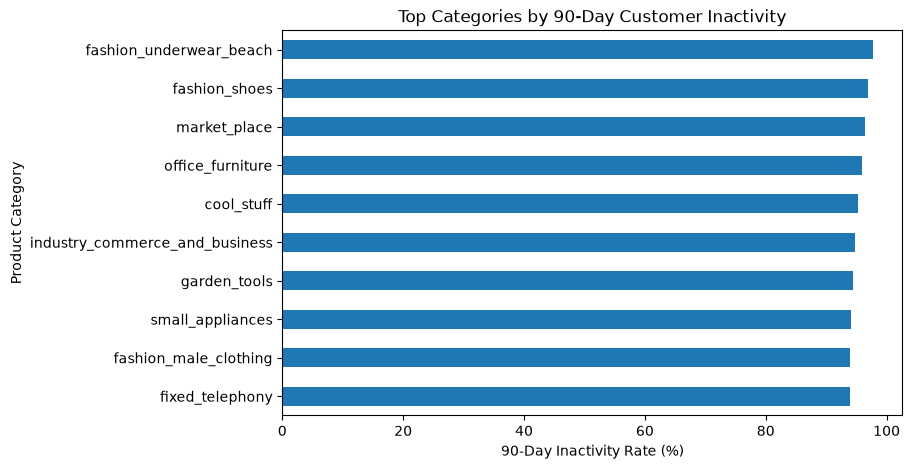

In [119]:
category_churn_filtered.nlargest(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('90-Day Inactivity Rate (%)')
plt.ylabel('Product Category')
plt.title('Top Categories by 90-Day Customer Inactivity')
plt.show()

---

In [120]:
first_date = for_product.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].transform('min')

In [121]:
first_orders = for_product[
    for_product['order_purchase_timestamp'] == first_date
]

In [122]:
customer_order_count = for_customer.groupby(
    'customer_unique_id'
)['order_id'].nunique()

first_orders['made_second_purchase'] = (
    first_orders['customer_unique_id'].map(customer_order_count) >= 2
)

In [123]:
gateway = first_orders.groupby(
    'product_category_name_english'
)['made_second_purchase'].mean() * 100

gateway.sort_values(ascending=False)

product_category_name_english
diapers_and_hygiene                14.705882
la_cuisine                         14.285714
arts_and_craftmanship              13.636364
home_appliances                    13.524590
fashion_childrens_clothes          12.500000
                                     ...    
pc_gamer                            0.000000
security_and_services               0.000000
portable_kitchen_food_preparers     0.000000
party_supplies                      0.000000
tablets_printing_image              0.000000
Name: made_second_purchase, Length: 73, dtype: float64

In [124]:
gateway_size = first_orders.groupby(
    'product_category_name_english'
)['customer_unique_id'].nunique()

gateway_filtered = gateway[
    gateway_size >= 100
]

gateway_filtered.sort_values(ascending=False).head(10)

product_category_name_english
home_appliances             13.524590
fashion_underwear_beach      7.812500
fashion_bags_accessories     7.045216
fashion_male_clothing        6.349206
fashion_shoes                5.882353
furniture_decor              5.745829
furniture_living_room        5.601660
bed_bath_table               5.356298
food                         4.897959
air_conditioning             4.861111
Name: made_second_purchase, dtype: float64

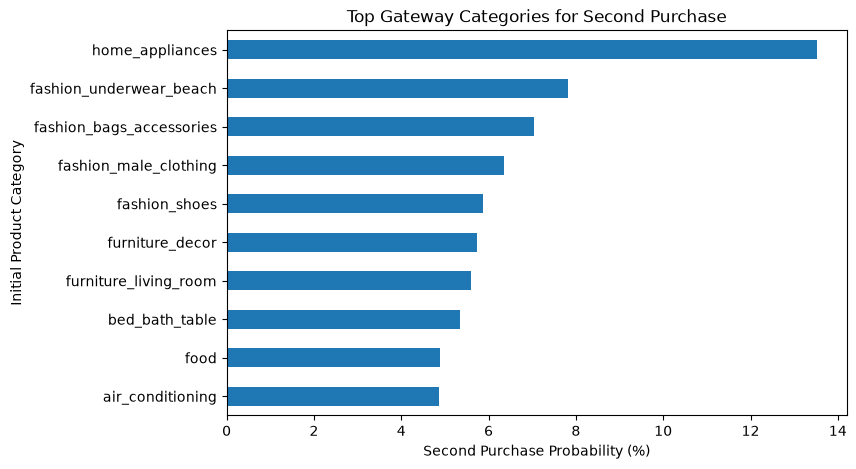

In [125]:
gateway_filtered.nlargest(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('Second Purchase Probability (%)')
plt.ylabel('Initial Product Category')
plt.title('Top Gateway Categories for Second Purchase')
plt.show()

# Part 4 — Reviews & Delivery Experience


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
customers = pd.read_csv('../../data/Brazilian E-Commerce/olist_customers_dataset.csv')
geolocations = pd.read_csv('../../data/Brazilian E-Commerce/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../../data/Brazilian E-Commerce/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../../data/Brazilian E-Commerce/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../../data/Brazilian E-Commerce/olist_order_reviews_dataset.csv')
orders_dataset = pd.read_csv('../../data/Brazilian E-Commerce/olist_orders_dataset.csv')
products = pd.read_csv('../../data/Brazilian E-Commerce/olist_products_dataset.csv')
sellers = pd.read_csv('../../data/Brazilian E-Commerce/olist_sellers_dataset.csv')
categories = pd.read_csv('../../data/Brazilian E-Commerce/product_category_name_translation.csv')

closed = pd.read_csv('../../data/Marketing Funnel/olist_closed_deals_dataset.csv')
qualified = pd.read_csv('../../data/Marketing Funnel/olist_marketing_qualified_leads_dataset.csv')

In [23]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [24]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [25]:
orders_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [26]:
orders_dataset.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [27]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [28]:
order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

# How do reviews differ between one-time and repeated customers?

In [77]:
customer_order_count = customers['customer_unique_id'].value_counts()

print(customer_order_count.head(10))

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64


In [78]:
customer_order_count

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [73]:
repeat_customers = customer_order_count[customer_order_count > 1]
len(repeat_customers)

2997

In [74]:
one_time_customers = customer_order_count[customer_order_count == 1]
len(one_time_customers)

93099

<Axes: title={'center': 'One-time vs Repeat Customers'}, xlabel='Customer Type', ylabel='Number of Customers'>

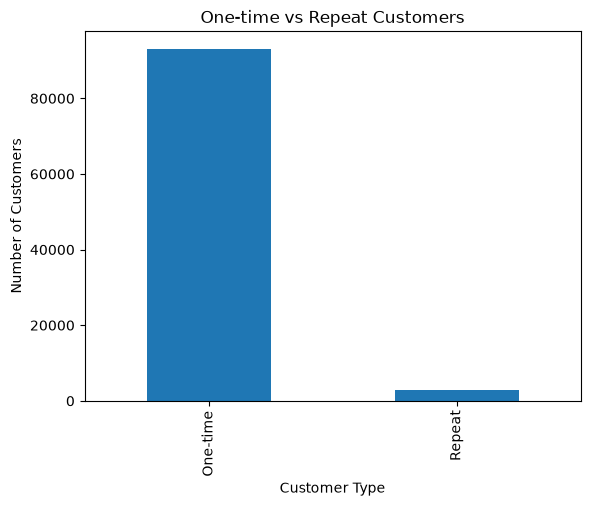

In [79]:
pd.Series([len(one_time_customers), len(repeat_customers)], index=['One-time', 'Repeat']).plot(kind='bar', xlabel='Customer Type', ylabel='Number of Customers', title='One-time vs Repeat Customers')

In [80]:
customer_orders = customers.merge(
    orders_dataset[['order_id', 'customer_id']],
    on='customer_id'
)

In [81]:
customer_reviews = customer_orders.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id'
)

In [83]:
repeat_reviews = customer_reviews[
    customer_reviews['customer_unique_id'].isin(repeat_customers.index)
]

repeat_reviews['review_score'].mean()

np.float64(4.121813870776526)

In [84]:
one_time_reviews = customer_reviews[
    customer_reviews['customer_unique_id'].isin(one_time_customers.index)
]

one_time_reviews['review_score'].mean()

np.float64(4.0838379687702755)

<Axes: title={'center': 'Review Scores by Customer Type'}, xlabel='Customer Type', ylabel='Average Review Score'>

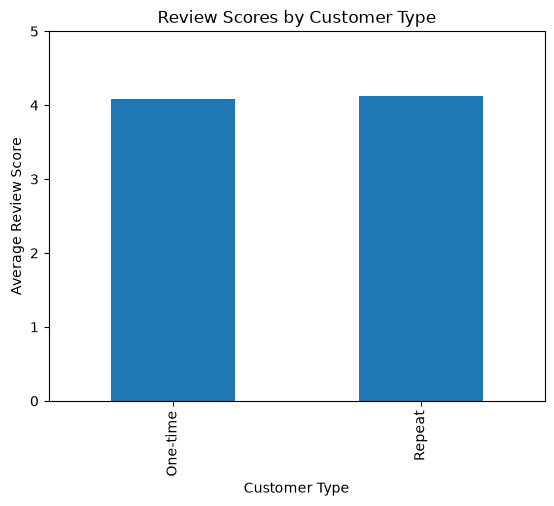

In [86]:
pd.Series({
    'One-time': one_time_reviews['review_score'].mean(),
    'Repeat': repeat_reviews['review_score'].mean()
}).plot(kind='bar', xlabel='Customer Type', ylabel='Average Review Score', title='Review Scores by Customer Type', ylim=(0, 5))

## Does every customer leave a reviews?

In [89]:
customer_reviews = customer_orders.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id'
)

In [91]:
total_customers = customers['customer_unique_id'].nunique()
total_customers

96096

In [92]:
review_customers = customer_reviews['customer_unique_id'].nunique()
review_customers

95380

In [95]:
print('Customers without reviews:', total_customers - review_customers)

Customers without reviews: 716


In [123]:
reviews = pd.Series({
    'With Review': review_customers,
    'Without Review': total_customers - review_customers
})

<Axes: title={'center': 'Customers With and Without Reviews'}>

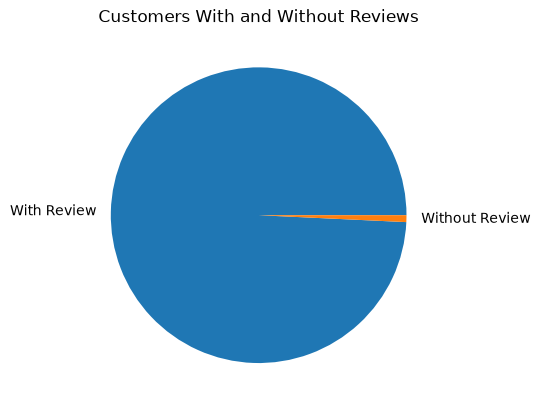

In [124]:
reviews.plot(
    kind='pie',
    title='Customers With and Without Reviews'
)

## Categorize delivery duration into groups and show each group as a percentage.

In [101]:
import datetime as dt

orders_dataset['order_purchase_timestamp'] = pd.to_datetime(
    orders_dataset['order_purchase_timestamp']
)

In [102]:
orders_dataset['order_delivered_customer_date'] = pd.to_datetime(
    orders_dataset['order_delivered_customer_date']
)

In [103]:
orders_dataset['delivery_days'] = (
    orders_dataset['order_delivered_customer_date'] - orders_dataset['order_purchase_timestamp']).dt.days

In [104]:
orders_dataset['delivery_days'].head(5)

0     8.0
1    13.0
2     9.0
3    13.0
4     2.0
Name: delivery_days, dtype: float64

In [112]:
def delivery_category(days):
    if pd.isna(days):
        return "Unknown"
    elif days <= 3:
        return "0-3 days"
    elif days <= 7:
        return "4-7 days"
    elif days <= 14:
        return "8-14 days"
    else:
        return "15+ days"
    
orders_dataset['delivery_category'] = orders_dataset['delivery_days'].apply(delivery_category)

In [113]:
orders_dataset['delivery_category'].value_counts()

delivery_category
8-14 days    36398
15+ days     26380
4-7 days     25096
0-3 days      8602
Unknown       2965
Name: count, dtype: int64

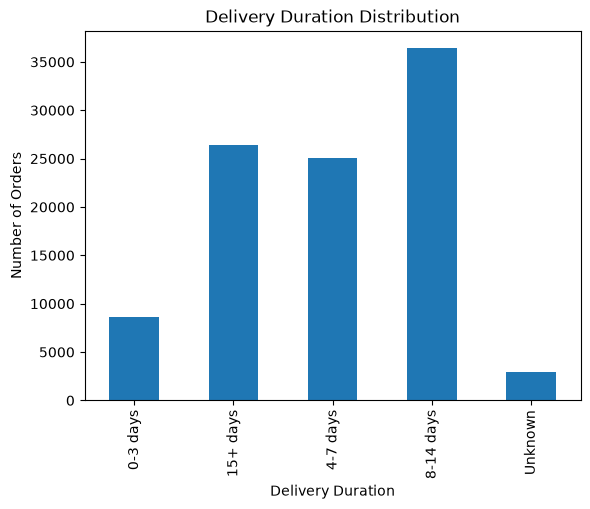

In [114]:
orders_dataset.groupby('delivery_category').size().plot(kind='bar',title='Delivery Duration Distribution', xlabel='Delivery Duration', ylabel='Number of Orders'
);

In [115]:
orders_dataset.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date               str
delivery_days                           float64
delivery_category                           str
dtype: object

In [116]:
orders_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,8-14 days
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.0,8-14 days
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,8-14 days
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13.0,8-14 days
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2.0,0-3 days
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,8.0,8-14 days
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,22.0,15+ days
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,24.0,15+ days
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,17.0,15+ days


In [118]:
delivery_counts = orders_dataset['delivery_category'].value_counts()
delivery_counts

delivery_category
8-14 days    36398
15+ days     26380
4-7 days     25096
0-3 days      8602
Unknown       2965
Name: count, dtype: int64

In [119]:
delivery_percentage = delivery_counts / delivery_counts.sum() * 100

In [120]:
delivery_percentage

delivery_category
8-14 days    36.602609
15+ days     26.528293
4-7 days     25.237075
0-3 days      8.650355
Unknown       2.981668
Name: count, dtype: float64

<Axes: >

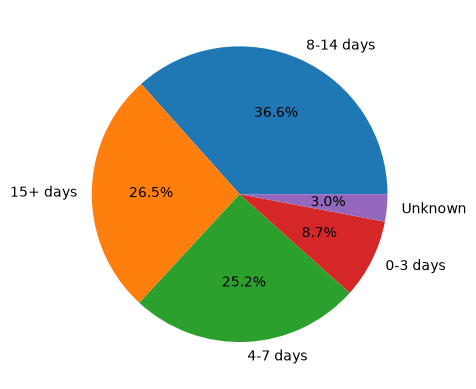

In [121]:
delivery_percentage.plot(kind='pie', autopct='%1.1f%%')

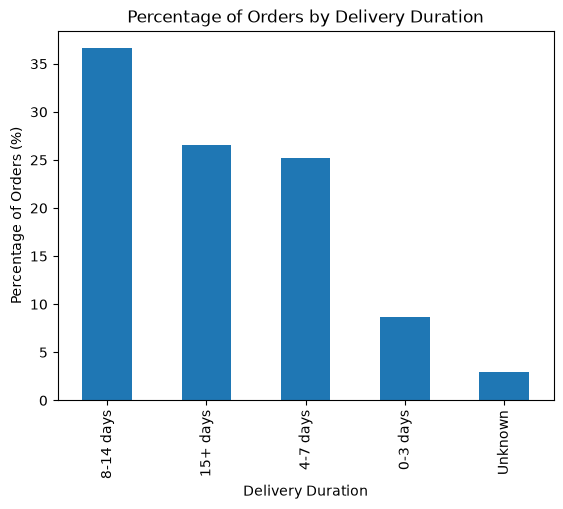

In [126]:
delivery_percentage.plot(kind='bar')
plt.xlabel('Delivery Duration')
plt.ylabel('Percentage of Orders (%)')
plt.title('Percentage of Orders by Delivery Duration')
plt.show()